# 05 — Ablation Study: Effect of fe02cr14

Compares GP and MLP performance with vs without fe02cr14.

fe02cr14 is the most problematic tag:
- Mixed FM/AFM initialisation (pinning paradox)
- Tier D: vcr geometry flag (post-BFGS SCF non-convergence)
- Tier E: cubic enforcement residual
- Mixed-threshold hydro.dat

**Datasets:** raw and corrected, with and without fe02cr14  
**Models:** GP (Matérn-5/2, fix_sigma2=np.var(y)) and MLP  
**Outputs:** `../analysis/ablation_fe02cr14_*.png/csv`

---
## Cell 1 — Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle, sys, os
import warnings; warnings.filterwarnings('ignore')
plt.rcParams.update({'font.size': 12, 'figure.dpi': 120})

sys.path.insert(0, os.path.dirname(os.path.abspath('data_utils.py')))
from data_utils import (load_data, plot_loo_residuals,
                        LeaveOneOut, mean_absolute_error, r2_score,
                        TARGETS, PALETTE, N_ATOMS)
from gp_scratch import GaussianProcessScratch, KERNELS

print('Imports OK')

/home/sayeed/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


Imports OK


---
## Cell 2 — Load four dataset variants

In [2]:
ABLATION_TAG = 'fe02cr14'

CSV_PATHS = {
    'raw':       '../analysis/elastic_constants_fecr_raw.csv',
    'corrected': '../analysis/elastic_constants_fecr_corrected.csv',
}

variants = {}

for csv_key, csv_path in CSV_PATHS.items():
    for ablated in [False, True]:
        d  = load_data(csv_path)
        df = d['df'].copy()

        if ablated:
            mask = df['tag'] != ABLATION_TAG
            df   = df[mask].reset_index(drop=True)
            key  = f'{csv_key}_no14'
            label = f'{csv_key} (n={len(df)}, no fe02cr14)'
        else:
            key   = csv_key
            label = f'{csv_key} (n={len(df)}, full)'

        if 'x_cr' not in df.columns:
            df['x_cr'] = df['n_cr'] / float(N_ATOMS)
        if 'B' not in df.columns:
            df['B'] = (df['C11'] + 2*df['C12']) / 3.0

        for col, default in [('afm_init', False),
                              ('vcr_geometry_flag', False),
                              ('loose_thr', False),
                              ('cubic_enforcement_residual', False)]:
            if col not in df.columns:
                df[col] = default

        X            = df['x_cr'].values.reshape(-1, 1)
        X_pred       = np.linspace(0, 1, 200).reshape(-1, 1)
        x_pred_atoms = (X_pred * N_ATOMS).flatten()

        noise_gpa = {
            'C11': df['noise_C11_2C12'].values.astype(float),
            'C12': df['noise_C11_C12'].values.astype(float),
            'C44': df['noise_C44'].values.astype(float),
        }
        alpha = {t: noise_gpa[t]**2 for t in TARGETS}
        tgt   = {t: df[t].values.astype(float) for t in TARGETS}
        tier  = np.where(df['n_cr'] <= 9,  'A',
                np.where(df['n_cr'] <= 13, 'B', 'C'))

        variants[key] = dict(
            df             = df,
            X              = X,
            X_pred         = X_pred,
            x_pred_atoms   = x_pred_atoms,
            targets        = tgt,
            alpha          = alpha,
            noise_gpa      = noise_gpa,
            flagged        = df['loose_thr'].values.astype(bool),
            vcr_geometry   = df['vcr_geometry_flag'].values.astype(bool),
            cubic_enforced = df['cubic_enforcement_residual'].values.astype(bool),
            tier           = tier,
            label          = label,
            ablated        = ablated,
            csv_key        = csv_key,
            gp_store       = {},
            mlp_store      = {},
        )
        print(f'  {key:22s}: {len(df)} tags')

print('\nVariants ready:', list(variants.keys()))


Loaded 17 tags — mode: RAW
tag            n_cr  σ C11+2C12  σ C11-C12   σ C44   afm  vcr_geo  cub_enf
--------------------------------------------------------------------
fe16cr00          0       1.000      1.000   1.000 False    False    False
fe15cr01          1       1.000      1.000   1.000 False    False    False
fe14cr02          2       1.000      1.000   1.000 False    False    False
fe13cr03          3       1.000      1.000   1.000 False    False    False
fe12cr04          4       1.000      1.000   1.000 False    False    False
fe11cr05          5       1.000      1.000   1.000 False    False    False
fe10cr06          6       1.000      1.000   1.000 False    False    False
fe09cr07          7       1.000      1.000   1.000 False    False    False
fe08cr08          8       1.000      1.000   1.000 False    False    False
fe07cr09          9       1.000      1.000   1.000 False    False    False
fe06cr10         10       1.000      1.000   1.000 False    False    False
fe0

---
## Cell 3 — GP LOO-CV helper

In [3]:
def loo_cv_gp(gp_full, X, y, noise_var):
    loo = LeaveOneOut()
    loo_preds, loo_true = [], []
    for tr, te in loo.split(X):
        n_tr = len(tr)
        K    = gp_full.kernel_fn(X[tr], X[tr], gp_full.sigma2, gp_full.ell)
        K_n  = K + np.diag(noise_var[tr]) + 1e-8 * np.eye(n_tr)
        L    = np.linalg.cholesky(K_n)
        v    = np.linalg.solve(L, y[tr])
        av   = np.linalg.solve(L.T, v)
        K_s  = gp_full.kernel_fn(X[te], X[tr], gp_full.sigma2, gp_full.ell)
        loo_preds.append(float(K_s @ av))
        loo_true.append(float(y[te[0]]))
    loo_preds = np.array(loo_preds)
    loo_true  = np.array(loo_true)
    return dict(loo_preds=loo_preds, loo_true=loo_true,
                residuals=loo_true - loo_preds,
                mae=mean_absolute_error(loo_true, loo_preds),
                r2=r2_score(loo_true, loo_preds))

print('GP LOO helper defined.')

GP LOO helper defined.


---
## Cell 4 — Train GP on all four variants

In [4]:
for vkey, v in variants.items():
    print(f'\n{"─"*50}')
    print(f'GP — {v["label"]}')
    print(f'{"─"*50}')
    for tname in TARGETS:
        y         = v['targets'][tname]
        noise_var = v['alpha'][tname]
        gp = GaussianProcessScratch(kernel='matern52', n_restarts=10)
        gp.fit(v['X'], y, noise_var=noise_var, fix_sigma2=np.var(y))
        loo     = loo_cv_gp(gp, v['X'], y, noise_var)
        mu, sig = gp.predict(v['X_pred'], return_std=True)
        v['gp_store'][tname] = dict(gp=gp, loo=loo, mu=mu, std=sig,
                                    mae=loo['mae'], r2=loo['r2'],
                                    residuals=loo['residuals'])
        print(f'  {tname}: σ²={gp.sigma2:.1f}  ℓ={gp.ell:.4f}  '
              f'MAE={loo["mae"]:.2f} GPa  R²={loo["r2"]:.4f}')


──────────────────────────────────────────────────
GP — raw (n=17, full)
──────────────────────────────────────────────────
  C11: σ²=7329.5  ℓ=0.1299  MAE=45.87 GPa  R²=0.5874
  C12: σ²=1340.7  ℓ=0.0960  MAE=32.69 GPa  R²=0.0434
  C44: σ²=65.7  ℓ=0.4421  MAE=3.54 GPa  R²=0.6521

──────────────────────────────────────────────────
GP — raw (n=16, no fe02cr14)
──────────────────────────────────────────────────
  C11: σ²=6595.0  ℓ=0.1364  MAE=38.80 GPa  R²=0.6533
  C12: σ²=1413.5  ℓ=0.1069  MAE=24.39 GPa  R²=0.4165
  C44: σ²=65.1  ℓ=0.4399  MAE=3.72 GPa  R²=0.6227

──────────────────────────────────────────────────
GP — corrected (n=17, full)
──────────────────────────────────────────────────
  C11: σ²=7329.5  ℓ=0.1696  MAE=31.35 GPa  R²=0.7760
  C12: σ²=1340.7  ℓ=0.1411  MAE=20.54 GPa  R²=0.5239
  C44: σ²=65.7  ℓ=0.4268  MAE=4.15 GPa  R²=0.5934

──────────────────────────────────────────────────
GP — corrected (n=16, no fe02cr14)
──────────────────────────────────────────────────
  C11:

---
## Cell 5 — MLP class and LOO helper

In [5]:
class MLP:
    def __init__(self, hidden=(16,16), lr=1e-2, n_epochs=3000, lam=1e-3, seed=42):
        self.hidden=hidden; self.lr=lr; self.n_epochs=n_epochs
        self.lam=lam; self.seed=seed; self.loss_history=[]

    def _init_params(self, layer_sizes):
        rng=np.random.default_rng(self.seed); self.W=[]; self.b=[]
        for n_in,n_out in zip(layer_sizes[:-1],layer_sizes[1:]):
            self.W.append(rng.normal(0,np.sqrt(2./n_in),(n_in,n_out)))
            self.b.append(np.zeros(n_out))

    def _forward(self, X):
        A=[X]
        for i,(W,b) in enumerate(zip(self.W,self.b)):
            Z=A[-1]@W+b
            A.append(np.tanh(Z) if i<len(self.W)-1 else Z)
        return A

    def _backward(self, A, y, sw):
        n=len(y); dWs=[]; dbs=[]
        delta=(-2*sw*(y-A[-1].flatten())/n).reshape(-1,1)
        for i in reversed(range(len(self.W))):
            dWs.insert(0, A[i].T@delta+self.lam*self.W[i])
            dbs.insert(0, delta.sum(axis=0))
            if i>0: delta=(delta@self.W[i].T)*(1-A[i]**2)
        return dWs,dbs

    def fit(self, X, y, sample_weight=None):
        if sample_weight is None: sample_weight=np.ones(len(y))
        sw=sample_weight/sample_weight.sum()*len(y)
        self.X_mean,self.X_std=X.mean(),X.std()+1e-8
        self.y_mean,self.y_std=y.mean(),y.std()+1e-8
        Xn=(X-self.X_mean)/self.X_std; yn=(y-self.y_mean)/self.y_std
        sizes=[1]+list(self.hidden)+[1]; self._init_params(sizes)
        m=[np.zeros_like(W) for W in self.W]; v=[np.zeros_like(W) for W in self.W]
        mb=[np.zeros_like(b) for b in self.b]; vb=[np.zeros_like(b) for b in self.b]
        b1,b2,eps=0.9,0.999,1e-8; self.loss_history=[]
        for ep in range(1,self.n_epochs+1):
            A=self._forward(Xn); pred=A[-1].flatten()
            loss=(np.sum(sw*(yn-pred)**2)/len(yn)
                  +self.lam*sum(np.sum(W**2) for W in self.W))
            self.loss_history.append(loss)
            dWs,dbs=self._backward(A,yn,sw)
            for i in range(len(self.W)):
                m[i]=b1*m[i]+(1-b1)*dWs[i]; v[i]=b2*v[i]+(1-b2)*dWs[i]**2
                mb[i]=b1*mb[i]+(1-b1)*dbs[i]; vb[i]=b2*vb[i]+(1-b2)*dbs[i]**2
                mc=m[i]/(1-b1**ep); vc=v[i]/(1-b2**ep)
                mbc=mb[i]/(1-b1**ep); vbc=vb[i]/(1-b2**ep)
                self.W[i]-=self.lr*mc/(np.sqrt(vc)+eps)
                self.b[i]-=self.lr*mbc/(np.sqrt(vbc)+eps)
        return self

    def predict(self, X):
        Xn=(X-self.X_mean)/self.X_std
        return self._forward(Xn)[-1].flatten()*self.y_std+self.y_mean


def mlp_loo(X, y, sw, hidden, lr, lam, n_epochs):
    loo=LeaveOneOut(); preds=[]; trues=[]
    for tr,te in loo.split(X):
        m=MLP(hidden=hidden,lr=lr,n_epochs=n_epochs,lam=lam)
        m.fit(X[tr],y[tr],sample_weight=sw[tr])
        preds.append(float(m.predict(X[te]))); trues.append(float(y[te[0]]))
    preds=np.array(preds); trues=np.array(trues)
    return mean_absolute_error(trues,preds),r2_score(trues,preds),preds,trues

print('MLP class and LOO helper defined.')

MLP class and LOO helper defined.


---
## Cell 6 — Train MLP on all four variants

In [6]:
HIDDEN_OPTS=[(8,8),(16,16)]; LR_OPTS=[5e-3,1e-2]
LAM_OPTS=[1e-3,1e-2]; N_EPOCHS=3000

for vkey,v in variants.items():
    print(f'\n{"─"*50}')
    print(f'MLP — {v["label"]}')
    print(f'{"─"*50}')
    for tname in TARGETS:
        y=v['targets'][tname]
        noise=v['noise_gpa'][tname]
        w=1.0/(noise**2); w=w/w.sum()*len(w)
        best_mae=np.inf; best_p=None
        for hid in HIDDEN_OPTS:
            for lr in LR_OPTS:
                for lam in LAM_OPTS:
                    mae,r2,_,_=mlp_loo(v['X'],y,w,hid,lr,lam,N_EPOCHS)
                    if mae<best_mae:
                        best_mae=mae; best_p={'hidden':hid,'lr':lr,'lam':lam}
        model=MLP(hidden=best_p['hidden'],lr=best_p['lr'],
                  n_epochs=N_EPOCHS,lam=best_p['lam'])
        model.fit(v['X'],y,sample_weight=w)
        mae,r2,loo_preds,loo_true=mlp_loo(
            v['X'],y,w,best_p['hidden'],best_p['lr'],best_p['lam'],N_EPOCHS)
        v['mlp_store'][tname]=dict(
            mu=model.predict(v['X_pred']),mae=mae,r2=r2,
            loo_true=loo_true,loo_preds=loo_preds,
            residuals=loo_true-loo_preds,best_params=best_p)
        print(f'  {tname}: h={best_p["hidden"]}  MAE={mae:.2f} GPa  R²={r2:.4f}')


──────────────────────────────────────────────────
MLP — raw (n=17, full)
──────────────────────────────────────────────────
  C11: h=(8, 8)  MAE=19.24 GPa  R²=0.9191
  C12: h=(8, 8)  MAE=15.59 GPa  R²=0.7013
  C44: h=(8, 8)  MAE=3.26 GPa  R²=0.6965

──────────────────────────────────────────────────
MLP — raw (n=16, no fe02cr14)
──────────────────────────────────────────────────
  C11: h=(8, 8)  MAE=18.63 GPa  R²=0.9145
  C12: h=(8, 8)  MAE=11.67 GPa  R²=0.8252
  C44: h=(8, 8)  MAE=3.52 GPa  R²=0.6631

──────────────────────────────────────────────────
MLP — corrected (n=17, full)
──────────────────────────────────────────────────
  C11: h=(16, 16)  MAE=20.52 GPa  R²=0.9109
  C12: h=(16, 16)  MAE=15.39 GPa  R²=0.6827
  C44: h=(16, 16)  MAE=3.65 GPa  R²=0.6839

──────────────────────────────────────────────────
MLP — corrected (n=16, no fe02cr14)
──────────────────────────────────────────────────
  C11: h=(8, 8)  MAE=19.27 GPa  R²=0.9030
  C12: h=(16, 16)  MAE=12.97 GPa  R²=0.7977
  C

---
## Cell 7 — Performance summary table

In [7]:
rows=[]
for vkey,v in variants.items():
    for model_name,store_key in [('GP','gp_store'),('MLP','mlp_store')]:
        for tname in TARGETS:
            res=v[store_key][tname]
            rows.append({'variant':vkey,'model':model_name,'target':tname,
                         'ablated':v['ablated'],'csv':v['csv_key'],
                         'MAE':round(res['mae'],2),'R2':round(res['r2'],4)})

summary=pd.DataFrame(rows)
pd.set_option('display.float_format','{:.3f}'.format)
print('MAE (GPa):')
print(summary.pivot_table(index=['model','target'],columns='variant',values='MAE').to_string())
print()
print('R²:')
print(summary.pivot_table(index=['model','target'],columns='variant',values='R2').to_string())
pd.reset_option('display.float_format')
summary.to_csv('../analysis/ablation_fe02cr14_summary.csv',index=False)
print('\nSaved: ablation_fe02cr14_summary.csv')

MAE (GPa):
variant       corrected  corrected_no14    raw  raw_no14
model target                                            
GP    C11        31.350          30.550 45.870    38.800
      C12        20.540          18.090 32.690    24.390
      C44         4.150           4.230  3.540     3.720
MLP   C11        20.520          19.270 19.240    18.630
      C12        15.390          12.970 15.590    11.670
      C44         3.650           3.700  3.260     3.520

R²:
variant       corrected  corrected_no14   raw  raw_no14
model target                                           
GP    C11         0.776           0.762 0.587     0.653
      C12         0.524           0.630 0.043     0.416
      C44         0.593           0.572 0.652     0.623
MLP   C11         0.911           0.903 0.919     0.914
      C12         0.683           0.798 0.701     0.825
      C44         0.684           0.658 0.697     0.663

Saved: ablation_fe02cr14_summary.csv


---
## Cell 8 — Prediction overlay: full vs ablated

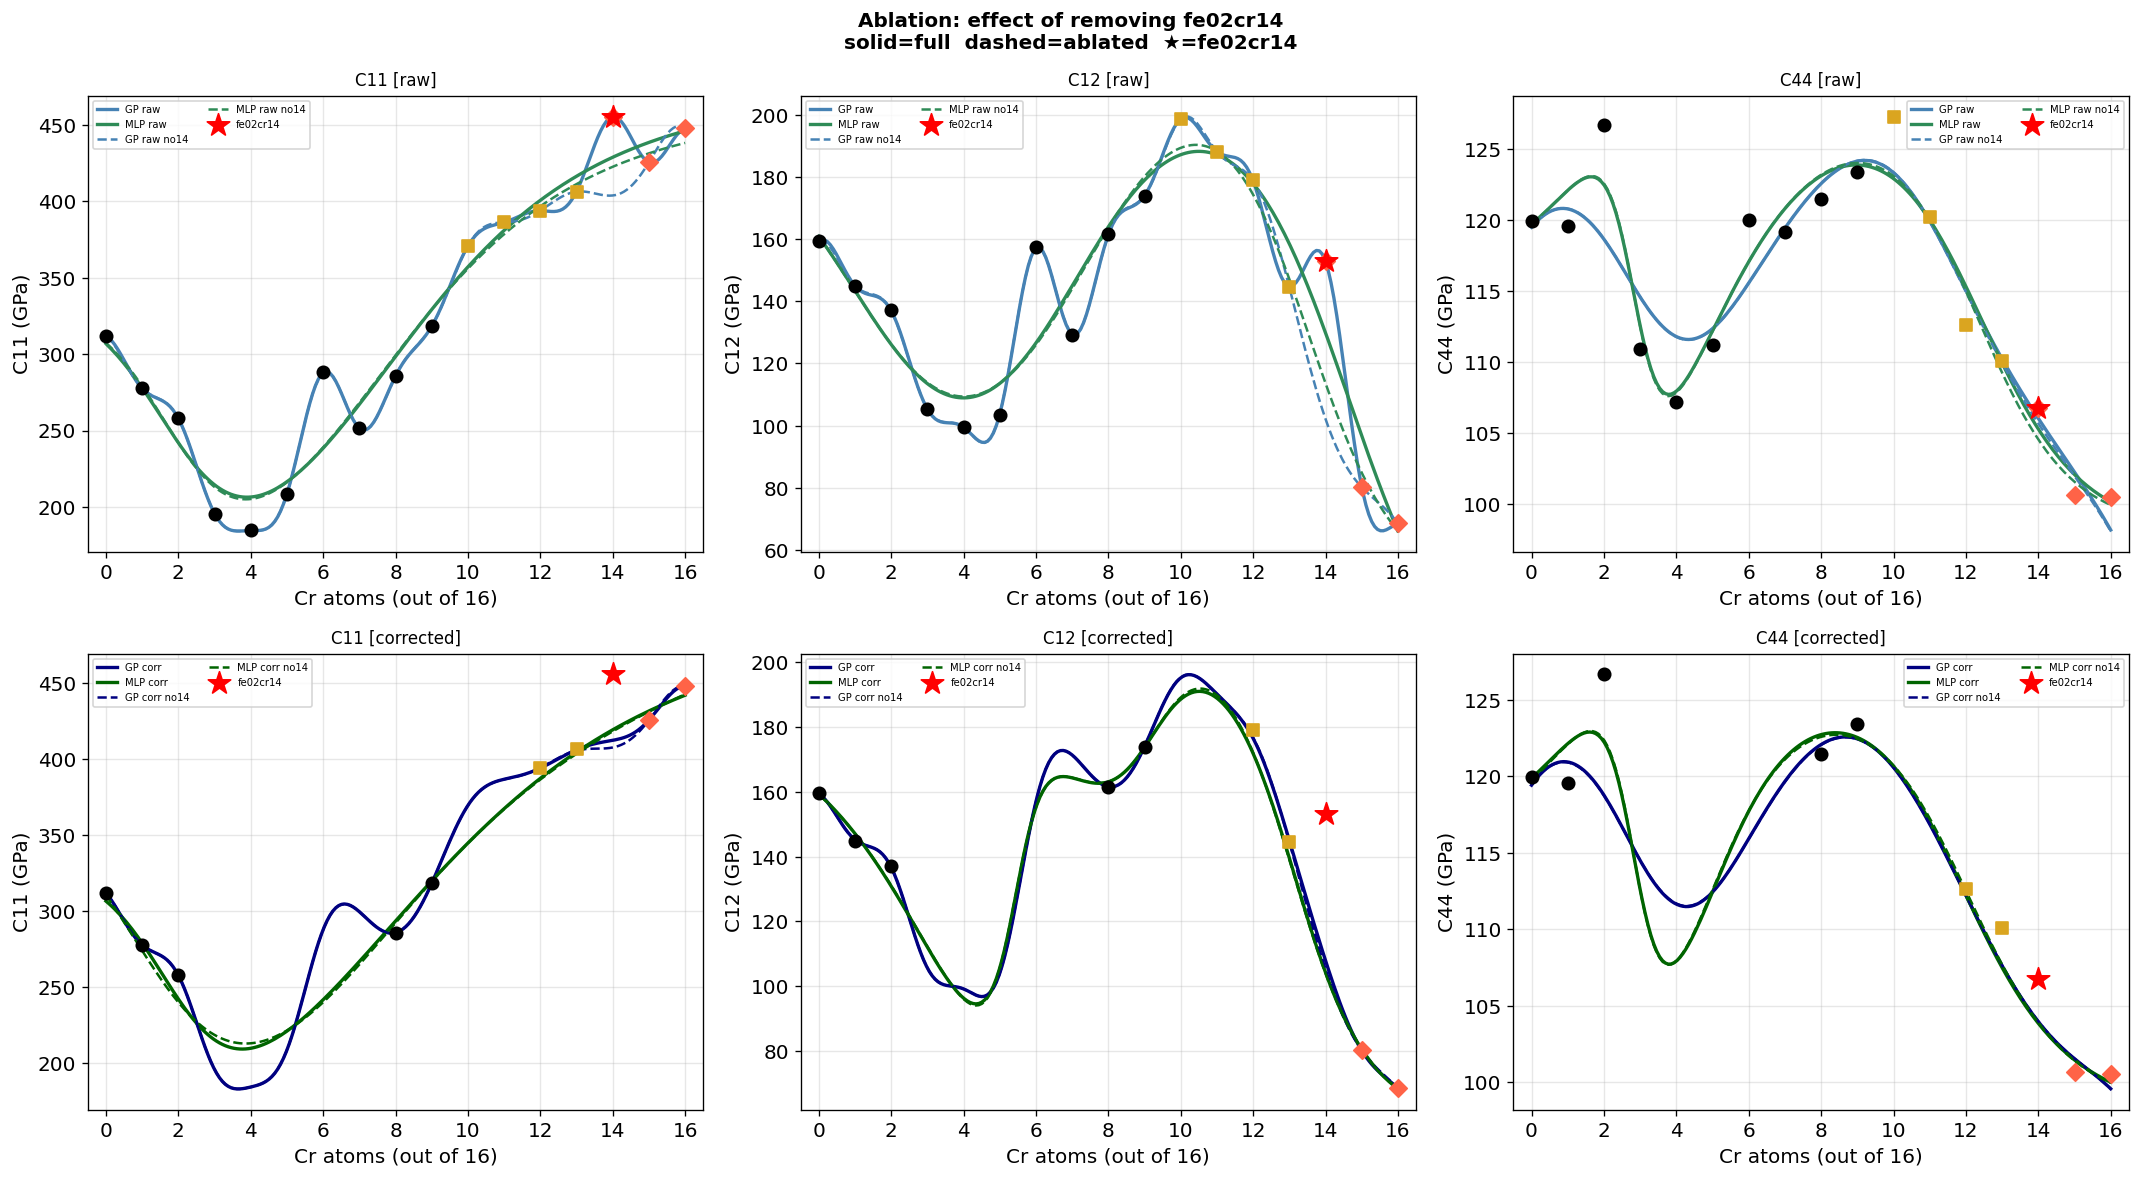

Saved: ablation_fe02cr14_predictions.png


In [8]:
tier_specs=[('A','black','o'),('B','goldenrod','s'),('C','tomato','D')]

line_styles={
    'raw_full':       dict(color='steelblue', ls='-',  lw=2.0,label='GP raw'),
    'raw_no14':       dict(color='steelblue', ls='--', lw=1.5,label='GP raw no14'),
    'corrected_full': dict(color='navy',      ls='-',  lw=2.0,label='GP corr'),
    'corrected_no14': dict(color='navy',      ls='--', lw=1.5,label='GP corr no14'),
}
mlp_styles={
    'raw_full':       dict(color='seagreen',  ls='-',  lw=2.0,label='MLP raw'),
    'raw_no14':       dict(color='seagreen',  ls='--', lw=1.5,label='MLP raw no14'),
    'corrected_full': dict(color='darkgreen', ls='-',  lw=2.0,label='MLP corr'),
    'corrected_no14': dict(color='darkgreen', ls='--', lw=1.5,label='MLP corr no14'),
}

fig,axes=plt.subplots(2,3,figsize=(18,10))
for row_idx,csv_key in enumerate(['raw','corrected']):
    for col_idx,tname in enumerate(TARGETS):
        ax=axes[row_idx,col_idx]
        for vkey,v in variants.items():
            if v['csv_key']!=csv_key: continue
            suffix='no14' if v['ablated'] else 'full'
            sk=f'{csv_key}_{suffix}'
            ax.plot(v['x_pred_atoms'],v['gp_store'][tname]['mu'],**line_styles[sk])
            ax.plot(v['x_pred_atoms'],v['mlp_store'][tname]['mu'],**mlp_styles[sk])
        v_full=variants[csv_key]; df_f=v_full['df']
        for t_lbl,col_s,mk in tier_specs:
            m=((v_full['tier']==t_lbl)&~v_full['vcr_geometry']&~v_full['cubic_enforced'])
            if m.any():
                ax.scatter(df_f['n_cr'][m],v_full['targets'][tname][m],
                           color=col_s,s=55,marker=mk,zorder=5)
        m14=df_f['tag']==ABLATION_TAG
        if m14.any():
            ax.scatter(df_f['n_cr'][m14],v_full['targets'][tname][m14],
                       color='red',s=200,marker='*',zorder=7,label='fe02cr14')
        ax.set_xlabel('Cr atoms (out of 16)'); ax.set_ylabel(f'{tname} (GPa)')
        ax.set_title(f'{tname} [{csv_key}]',fontsize=10)
        ax.legend(fontsize=6,ncol=2); ax.grid(alpha=0.3); ax.set_xlim(-0.5,16.5)

plt.suptitle(f'Ablation: effect of removing {ABLATION_TAG}\nsolid=full  dashed=ablated  ★=fe02cr14',
             fontweight='bold',fontsize=12)
plt.tight_layout()
plt.savefig('../analysis/ablation_fe02cr14_predictions.png',bbox_inches='tight')
plt.show(); print('Saved: ablation_fe02cr14_predictions.png')

---
## Cell 9 — Metric delta plot

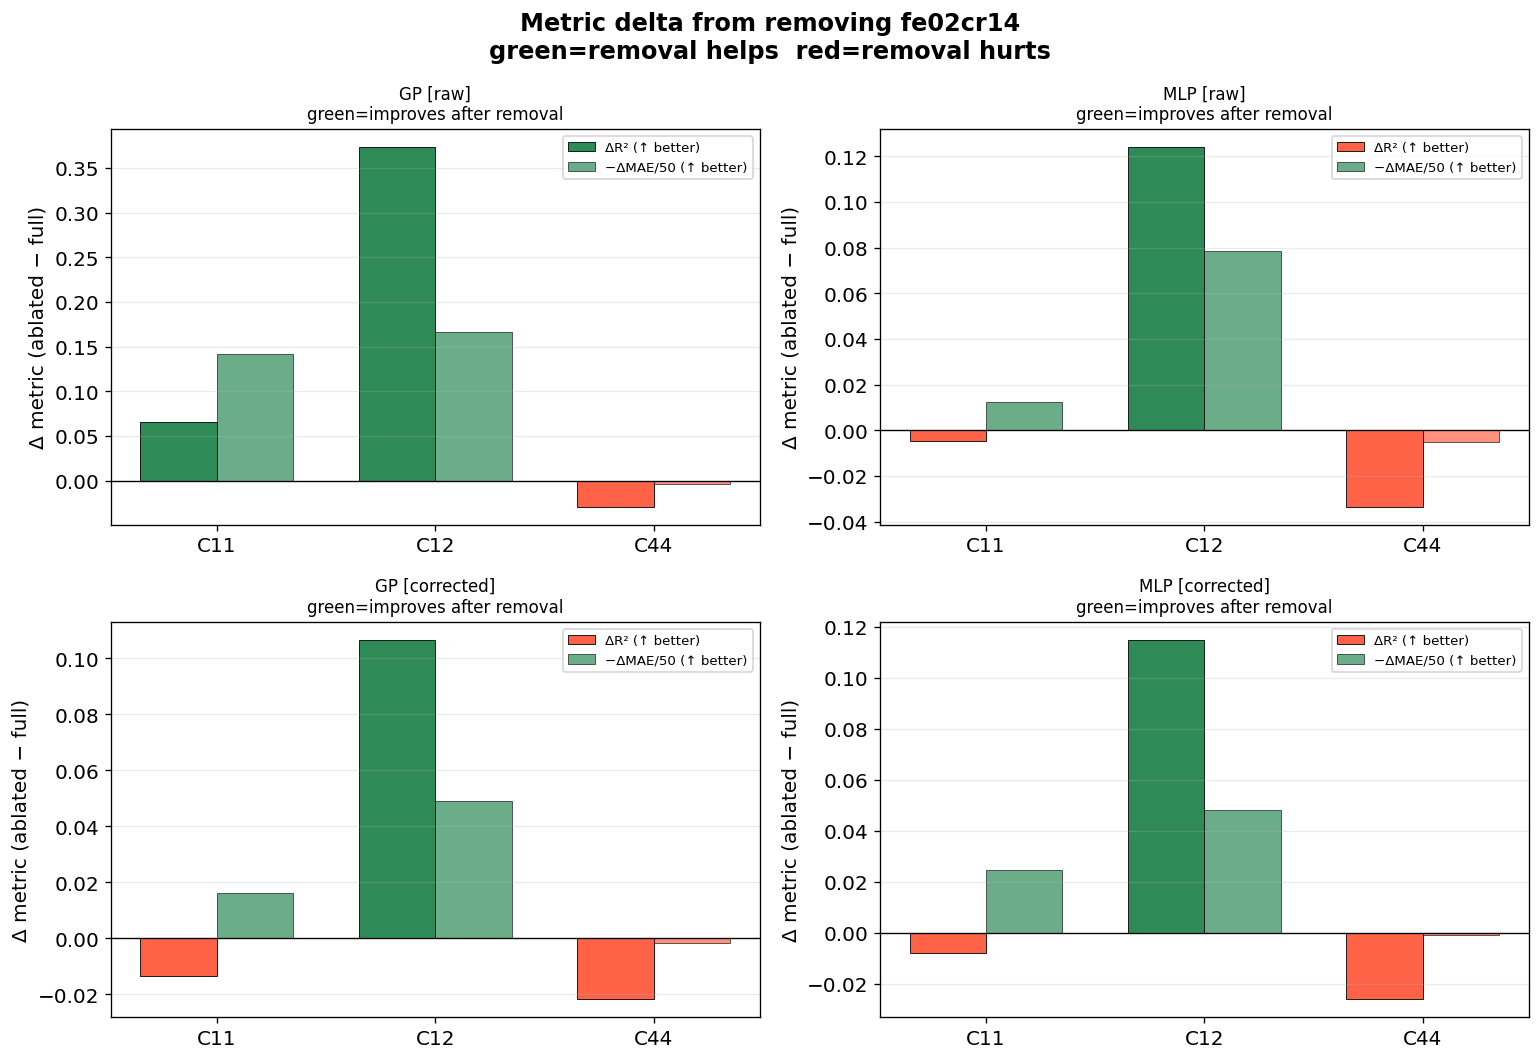

Saved: ablation_fe02cr14_delta.png


In [9]:
fig,axes=plt.subplots(2,2,figsize=(13,9))
combos=[('raw','GP'),('raw','MLP'),('corrected','GP'),('corrected','MLP')]

for idx,(csv_key,model_name) in enumerate(combos):
    ax=axes[idx//2,idx%2]
    store='gp_store' if model_name=='GP' else 'mlp_store'
    v_full=variants[csv_key]; v_abl=variants[f'{csv_key}_no14']
    delta_r2=[]; delta_mae=[]
    for tname in TARGETS:
        delta_r2.append(v_abl[store][tname]['r2']-v_full[store][tname]['r2'])
        delta_mae.append(v_abl[store][tname]['mae']-v_full[store][tname]['mae'])
    x=np.arange(len(TARGETS)); bw=0.35
    col_r2=['seagreen' if d>=0 else 'tomato' for d in delta_r2]
    col_mae=['tomato' if d>=0 else 'seagreen' for d in delta_mae]
    ax.bar(x-bw/2,delta_r2,bw,color=col_r2,edgecolor='k',lw=0.5,label='ΔR² (↑ better)')
    ax.bar(x+bw/2,[-d/50 for d in delta_mae],bw,color=col_mae,edgecolor='k',
           lw=0.5,label='−ΔMAE/50 (↑ better)',alpha=0.7)
    ax.axhline(0,color='k',lw=0.8)
    ax.set_xticks(x); ax.set_xticklabels(TARGETS)
    ax.set_title(f'{model_name} [{csv_key}]\ngreen=improves after removal',fontsize=10)
    ax.set_ylabel('Δ metric (ablated − full)')
    ax.legend(fontsize=8); ax.grid(alpha=0.25,axis='y')

plt.suptitle(f'Metric delta from removing {ABLATION_TAG}\ngreen=removal helps  red=removal hurts',
             fontweight='bold')
plt.tight_layout()
plt.savefig('../analysis/ablation_fe02cr14_delta.png',bbox_inches='tight')
plt.show(); print('Saved: ablation_fe02cr14_delta.png')

---
## Cell 10 — LOO residuals: full vs ablated (GP)

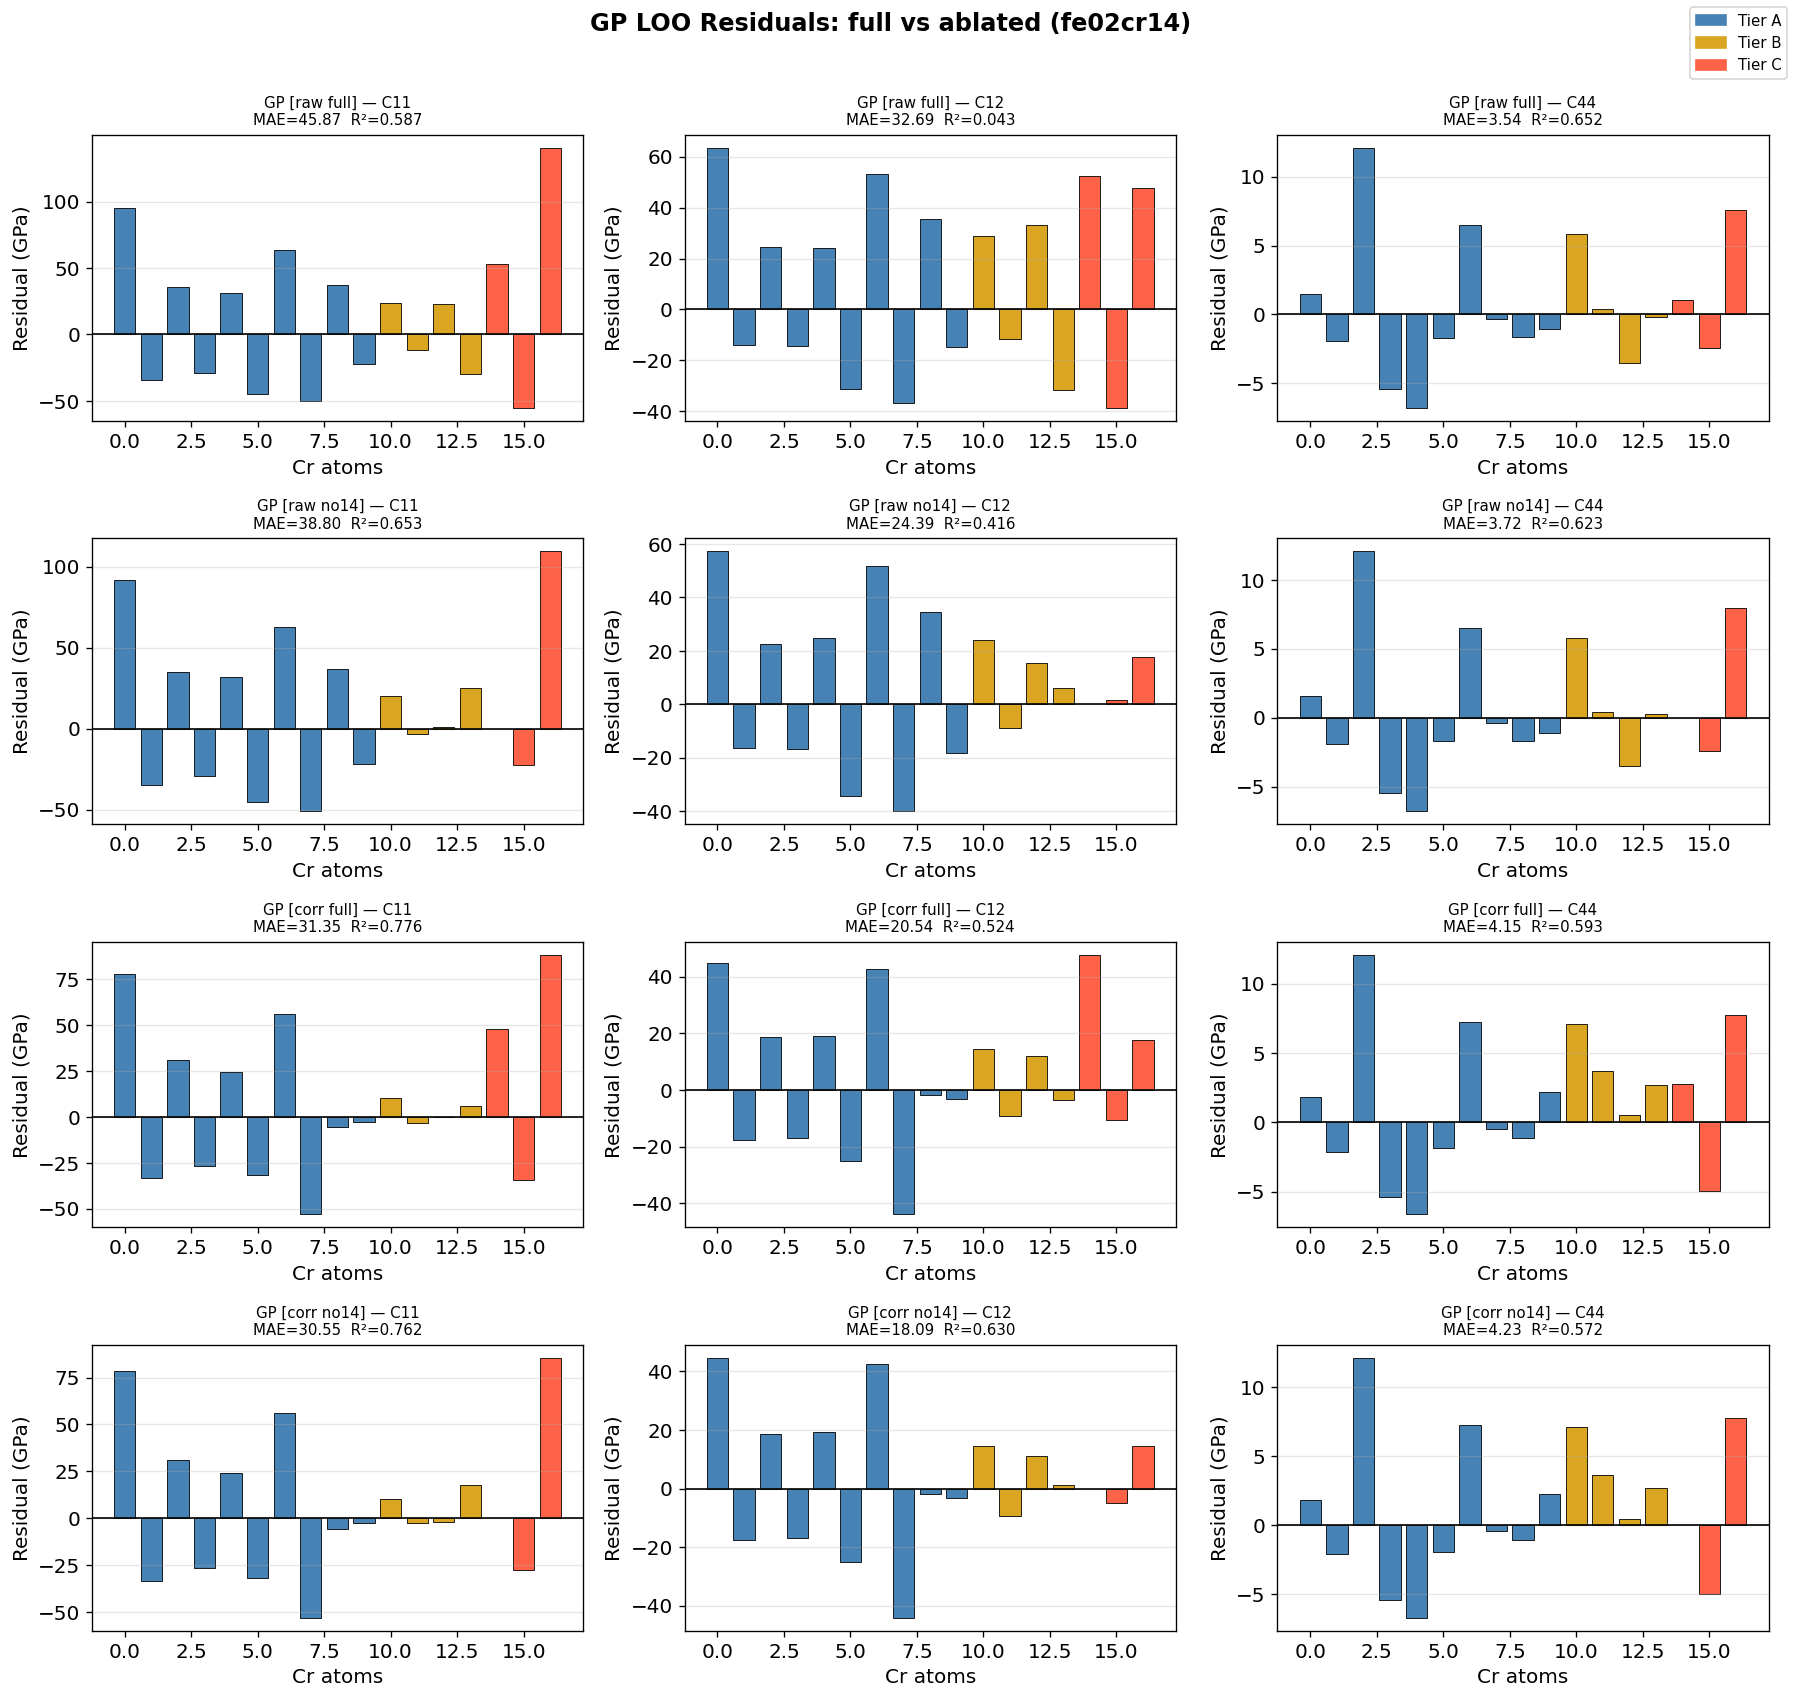

Saved: ablation_fe02cr14_residuals_gp.png


In [10]:
TIER_COL={'A':'steelblue','B':'goldenrod','C':'tomato'}
plot_order=[('raw',False,'raw full'),('raw',True,'raw no14'),
            ('corrected',False,'corr full'),('corrected',True,'corr no14')]

fig,axes=plt.subplots(4,3,figsize=(15,14))
for row_idx,(csv_key,ablated,row_label) in enumerate(plot_order):
    vkey=f'{csv_key}_no14' if ablated else csv_key
    v=variants[vkey]; cols=[TIER_COL[t] for t in v['tier']]
    for col_idx,tname in enumerate(TARGETS):
        ax=axes[row_idx,col_idx]; res=v['gp_store'][tname]
        ax.bar(v['df']['n_cr'].values,res['residuals'],color=cols,edgecolor='k',lw=0.5)
        ax.axhline(0,color='k',lw=1)
        ax.set_title(f'GP [{row_label}] — {tname}\nMAE={res["mae"]:.2f}  R²={res["r2"]:.3f}',fontsize=9)
        ax.set_xlabel('Cr atoms'); ax.set_ylabel('Residual (GPa)')
        ax.grid(alpha=0.3,axis='y')

from matplotlib.patches import Patch
tier_h=[Patch(color=TIER_COL[t],label=f'Tier {t}') for t in ['A','B','C']]
fig.legend(handles=tier_h,loc='upper right',fontsize=9)
plt.suptitle(f'GP LOO Residuals: full vs ablated ({ABLATION_TAG})',
             fontweight='bold',y=1.01)
plt.tight_layout()
plt.savefig('../analysis/ablation_fe02cr14_residuals_gp.png',bbox_inches='tight')
plt.show(); print('Saved: ablation_fe02cr14_residuals_gp.png')

---
## Cell 11 — Final summary

In [11]:
print('='*65)
print(f'ABLATION STUDY: effect of removing {ABLATION_TAG}')
print('='*65)
print()
for model_name,store_key in [('GP','gp_store'),('MLP','mlp_store')]:
    print(f'── {model_name} ─────────────────────────────────')
    print(f'  {"variant":<22} {"C11 R²":>8} {"C12 R²":>8} {"C44 R²":>8} '
          f'{"C11 MAE":>9} {"C12 MAE":>9} {"C44 MAE":>9}')
    print('  '+'-'*72)
    for vkey,v in variants.items():
        r=[v[store_key][t] for t in TARGETS]
        print(f'  {v["label"]:<22} '
              f'{r[0]["r2"]:>8.4f} {r[1]["r2"]:>8.4f} {r[2]["r2"]:>8.4f} '
              f'{r[0]["mae"]:>9.2f} {r[1]["mae"]:>9.2f} {r[2]["mae"]:>9.2f}')
    print()

print('Interpretation:')
print(f'  If metrics IMPROVE after removing {ABLATION_TAG}:')
print('    → that tag was pulling the model away from the true trend')
print(f'  If metrics WORSEN after removing {ABLATION_TAG}:')
print('    → that tag carries real physical information')
print()
print('Outputs saved to ../analysis/:')
for fn in ['ablation_fe02cr14_summary.csv',
           'ablation_fe02cr14_predictions.png',
           'ablation_fe02cr14_delta.png',
           'ablation_fe02cr14_residuals_gp.png']:
    print(f'  {fn}')

ABLATION STUDY: effect of removing fe02cr14

── GP ─────────────────────────────────
  variant                  C11 R²   C12 R²   C44 R²   C11 MAE   C12 MAE   C44 MAE
  ------------------------------------------------------------------------
  raw (n=17, full)         0.5874   0.0434   0.6521     45.87     32.69      3.54
  raw (n=16, no fe02cr14)   0.6533   0.4165   0.6227     38.80     24.39      3.72
  corrected (n=17, full)   0.7760   0.5239   0.5934     31.35     20.54      4.15
  corrected (n=16, no fe02cr14)   0.7624   0.6304   0.5716     30.55     18.09      4.23

── MLP ─────────────────────────────────
  variant                  C11 R²   C12 R²   C44 R²   C11 MAE   C12 MAE   C44 MAE
  ------------------------------------------------------------------------
  raw (n=17, full)         0.9191   0.7013   0.6965     19.24     15.59      3.26
  raw (n=16, no fe02cr14)   0.9145   0.8252   0.6631     18.63     11.67      3.52
  corrected (n=17, full)   0.9109   0.6827   0.6839     20